In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [2]:
user_ratings = pd.read_csv('data/AnimeList/UserAnimeList.csv', nrows=500000)

In [ ]:
# Keep only ratings > 0 (0 just means unrated in this dataset)
user_ratings = user_ratings[user_ratings['my_score'] > 0].copy()

# Encode usernames and anime_ids to range [0, n_unique-1]
user_enc = LabelEncoder()
user_ratings['user'] = user_enc.fit_transform(user_ratings['username'])
n_users = user_ratings['user'].nunique()

item_enc = LabelEncoder()
user_ratings['anime'] = item_enc.fit_transform(user_ratings['anime_id'])
n_anime = user_ratings['anime'].nunique()

print(f"Number of Users: {n_users}")
print(f"Number of Anime: {n_anime}")

# Normalize ratings to range [0, 1] for easier training
# Ratings are 1-10, so we can map them to 0-1
user_ratings['rating'] = user_ratings['my_score'].values.astype(np.float32) / 10.0

X = user_ratings[['user', 'anime']].values
y = user_ratings['rating'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Number of Users: 1449
Number of Anime: 10594


In [ ]:
import tensorflow as tf

train_ds = tf.data.Dataset.from_tensor_slices(((X_train[:, 0], X_train[:, 1]), y_train))\
    .shuffle(10000).batch(64)
test_ds = tf.data.Dataset.from_tensor_slices(((X_test[:, 0], X_test[:, 1]), y_test))\
    .batch(64)


In [ ]:
from tensorflow.keras import layers, Model, regularizers

def create_ncf_model(n_users, n_items, emb_size=50):
    # Inputs
    user_input = layers.Input(shape=(1,), name='user_input')
    item_input = layers.Input(shape=(1,), name='item_input')
    
    # Embeddings
    user_emb = layers.Embedding(n_users, emb_size, name='user_emb')(user_input)
    item_emb = layers.Embedding(n_items, emb_size, name='item_emb')(item_input)
    
    user_vec = layers.Flatten()(user_emb)
    item_vec = layers.Flatten()(item_emb)
    
    # Concatenate
    concat = layers.Concatenate()([user_vec, item_vec])
    
    res = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01))(concat)
    res = layers.Dropout(0.2)(res)
    
    res = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01))(res)
    res = layers.Dropout(0.2)(res)
    
    output = layers.Dense(1)(res)
    
    model = Model(inputs=[user_input, item_input], outputs=output)
    model.compile(optimizer='adam', loss='mse')
    return model

model = create_ncf_model(n_users, n_anime)


Epoch 1/5
3654/3654 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - loss: 0.0557 - val_loss: 0.0207
Epoch 2/5
3654/3654 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 0.0216 - val_loss: 0.0203
Epoch 3/5
3654/3654 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 0.0206 - val_loss: 0.0191
Epoch 4/5
3654/3654 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 0.0201 - val_loss: 0.0196
Epoch 5/5
3654/3654 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 0.0198 - val_loss: 0.0189


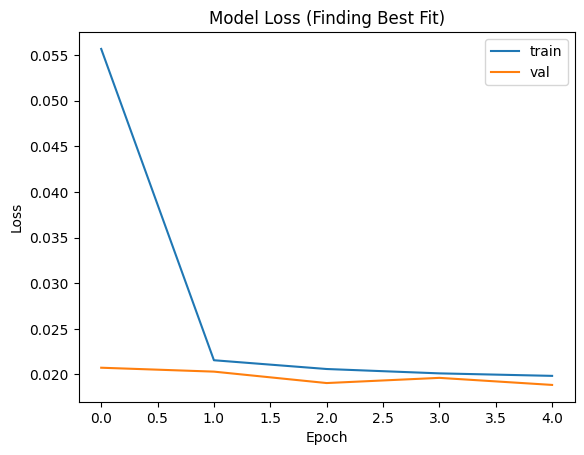

In [ ]:
import matplotlib.pyplot as plt

epochs = 5
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=epochs
)

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Model Loss (Finding Best Fit)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()
